## **Import Libraries**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime
import pickle

## **Load the Dataset**

In [4]:
data = pd.read_csv("raw_data.csv")
df = data.copy()

### Display basic information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [6]:
# Display the first 5 rows of the DataFrame
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## **Data Cleaning**

In [7]:
# Since 'Unnamed: 0' column is just an index column and doesn't add any value,
# we can drop it from the DataFrame
df.drop(columns=['Unnamed: 0'], inplace=True)

# Display the df to verify that the 'Unnamed: 0' column has been dropped
df.head(1)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


In [8]:
### Check missing values

# Calculate the number of missing values in each column
missing_values = df.isnull().sum()

# Create a table to display columns with missing values and their counts
missing_table = missing_values[missing_values > 0].to_frame(name='Missing Count')

# Display the table of columns with missing values
print("Columns with missing values:")
print(missing_table)

Columns with missing values:
            Missing Count
artists                 1
album_name              1
track_name              1


In [9]:
### Drop columns with too many missing values

col_threshold = 0.4    

df = df.loc[:, df.isnull().mean() < col_threshold]


In [10]:
### Drop rows with any missing values
df = df.dropna()


### Duplicate

In [11]:
# Find duplicated rows in the DataFrame
duplicated_rows = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicated_rows}")


Number of duplicated rows: 450


In [12]:
# Remove duplicates
df.drop_duplicates(inplace=True) 


In [13]:
# Reset index after dropping duplicates
df.reset_index(drop=True, inplace=True)

### Summary after basic cleaning

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113549 entries, 0 to 113548
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  str    
 1   artists           113549 non-null  str    
 2   album_name        113549 non-null  str    
 3   track_name        113549 non-null  str    
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           113549 non-nu

## **Exploratory Data Analysis**

In [15]:
# Display summary statistics of the numerical columns in the DataFrame
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113549.000000,1.135490e+05,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,33.324433,2.280814e+05,0.567031,0.642091,5.309452,-8.243408,0.637866,0.084674,0.314064,0.155703,0.213613,0.474205,122.175745,3.904218
std,22.283855,1.064131e+05,0.173409,0.251053,3.560147,5.011422,0.480620,0.105762,0.331906,0.309217,0.190462,0.259204,29.972954,0.432117
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741840e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296000,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615880e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048700,0.273000,0.683000,140.074000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Distribution of Popularity

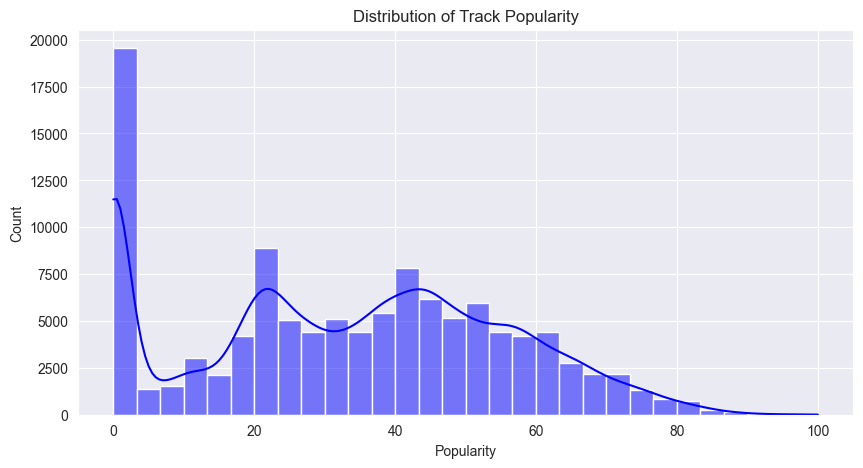

In [16]:
# set plot style
sns.set_style('darkgrid')

# plot histogram of popularity
plt.figure(figsize=(10, 5))     

sns.histplot(df['popularity'], bins=30, kde=True, color='blue')

plt.title('Distribution of Track Popularity')   
plt.xlabel('Popularity')                       
plt.ylabel('Count')                            
plt.show()                                      

Most songs have a moderate level of popularity, while only a relatively small number achieve very high popularity. This indicates that there is intense competition for popularity on Spotify.

### Top 10 most frequent artists

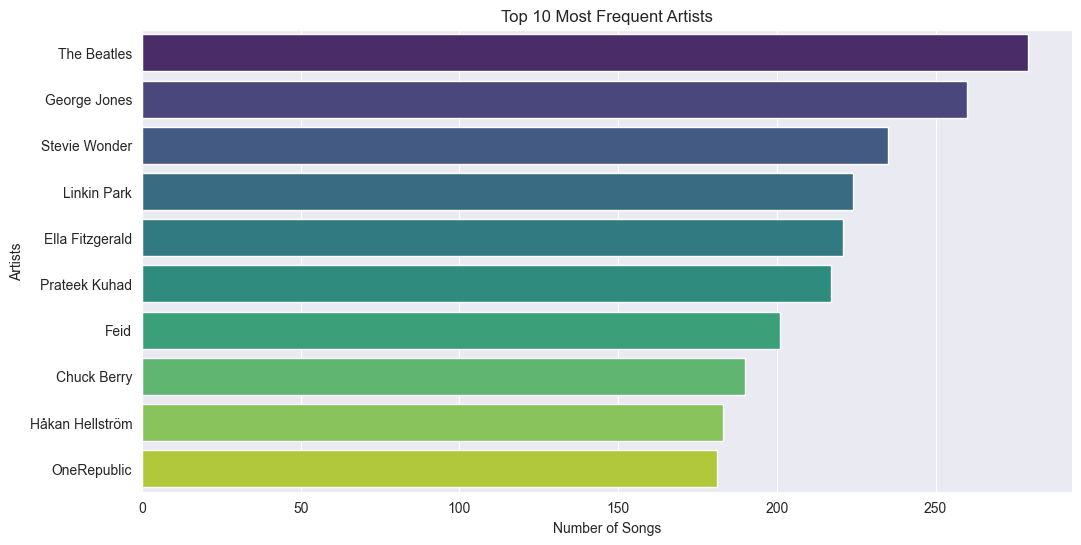

In [17]:
top_artists = df['artists'].value_counts().head(10)

plt.figure(figsize=(12, 6))        

sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis', hue=top_artists.index)

plt.title('Top 10 Most Frequent Artists')
plt.xlabel('Number of Songs')
plt.ylabel('Artists')
plt.show()

Some artists appear significantly more frequently in the dataset, indicating a high level of activity and music releases on Spotify.

### Correlation Matrix

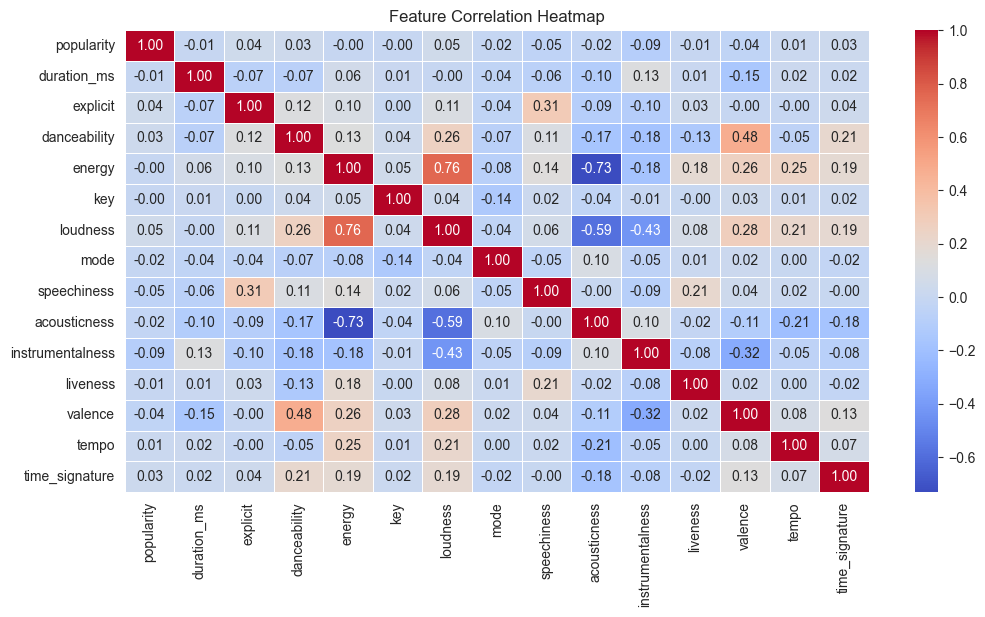

In [18]:
# compute correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# plot heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')
plt.show()

### Top 10 Most Popular Genres

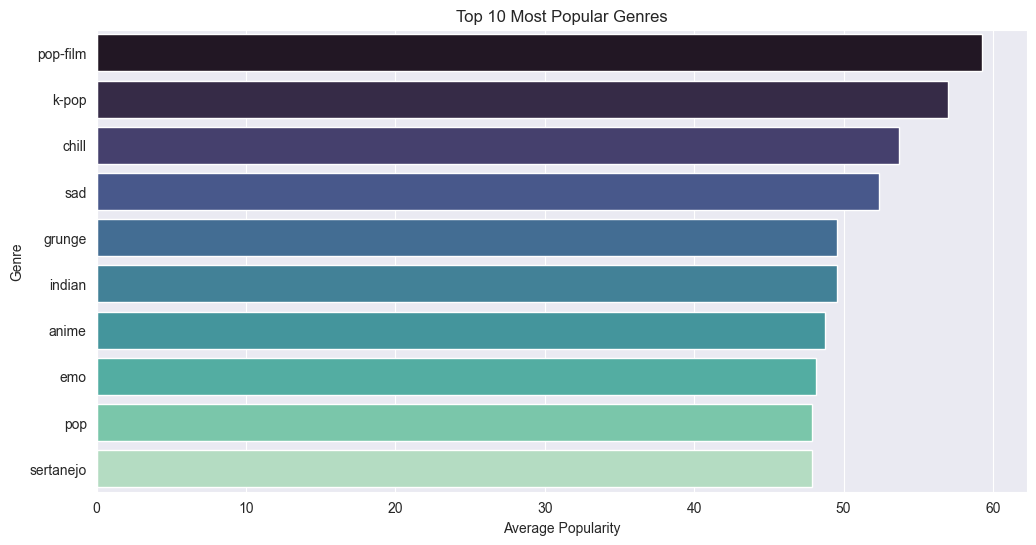

In [19]:
# average popularity by genre (top 10)

genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))     # kích thước biểu đồ

sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette='mako', hue=genre_popularity.index)

plt.title('Top 10 Most Popular Genres')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()

Genres such as pop-film, K-pop, and chill have the highest average popularity in the dataset. This indicates that Spotify users not only prefer trending music genres but also tend to listen to music based on emotions or entertainment content, such as movie soundtracks and relaxing playlists.

## Additional Feature Exploration

The group chose to further analyze the two features, explicit and loudness, because these variables show the highest positive correlation with popularity in the dataset, as illustrated in the heatmap. Exploring the relationship between these audio features and popularity helps identify the characteristics that may influence music listening trends and the overall popularity of songs on Spotify.

### Explicit vs Popularity

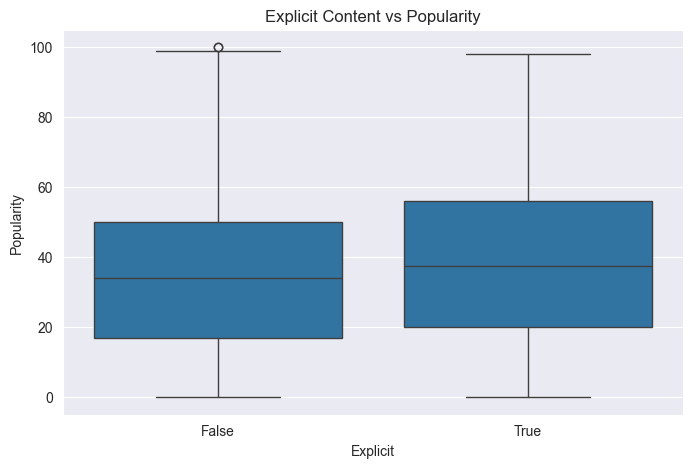

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['explicit'],
    y=df['popularity']
)

plt.title('Explicit Content vs Popularity')

plt.xlabel('Explicit')
plt.ylabel('Popularity')

plt.show()


Songs with explicit content tend to have a slightly higher average popularity compared to non-explicit songs. This reflects the trend of modern music on streaming platforms becoming increasingly open to more direct and expressive content.

### Loudness vs Popularity

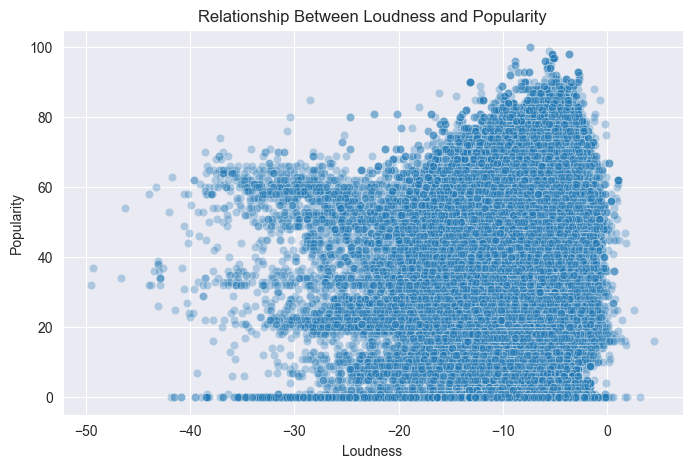

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['loudness'],
    y=df['popularity'],
    alpha=0.3
)

plt.title('Relationship Between Loudness and Popularity')

plt.xlabel('Loudness')
plt.ylabel('Popularity')

plt.show()

Loudness shows a slight positive correlation with popularity, as songs with higher popularity tend to appear more frequently among tracks with higher loudness levels. This reflects the trend that modern mainstream songs often feature stronger and more prominent sound on streaming platforms.